<a href="https://colab.research.google.com/github/hector-carpi/sprint7-telecom-analysis/blob/main/S7_Version_Estudiante_Project_ConnectaTel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')


In [ ]:
# mostrar las primeras 5 filas de plans
plans.head()


,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head()


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head()


,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset

print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)


plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())


id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?
  
 - city: pocos nulos → imputar o dejar NA
 - age: si hay -999 → sentinel
 - duration/length: dependen del tipo → probablemente normales

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users.describe()


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` Es una variable identificadora, no requiere limpieza ni análisis estadístico.
- La columna `age`  Existe un valor inválido (-999) que debe ser tratado.
- media (33.7) << mediana (47)
Indica que la distribución está sesgada artificialmente por el valor -999, después de limpiar, la media debería acercarse más a la mediana

In [ ]:
# explorar columnas numéricas de usage

usage.describe()


,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- La columna `id` identificador de cada registro de uso (no se analiza).
-  La columna `user_id`clave para relacionar datasets (correcta y consistente).
- Las columnas `duration` y `length`  Muchos valores nulos → esto puede parecer problema, pero depende del tipo de evento.
  
-  No hay errores estructurales en id o user_id
-  Los nulos en duration y length no deben imputarse, representan correctamente el comportamiento del sistema

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

users['city'].unique()


array(['Medellín', '?', 'CDMX', 'Bogotá', 'GDL', 'MTY', nan, 'Cali'],
      dtype=object)

In [ ]:
users['plan'].unique()

array(['Basico', 'Premium'], dtype=object)

- La columna `city` requiere limpieza (sentinel)
- La columna `plan`correcta y útil para análisis

In [ ]:
# explorar columna categórica de usage
usage['type'].unique()

array(['call', 'text'], dtype=object)

- La columna `type` correcta y útil para análisis

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?  
- ¿Qué acción tomarías?
- age = -999 → sentinel → reemplazar
- city = "?" → dato faltante → convertir a NA
- type → valores válidos: call / text

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')


In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()


2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, La presencia de fechas futuras sugiere errores de captura. Aunque su proporción es baja (~1%), su eliminación es necesaria para garantizar la consistencia temporal del análisis.
- Son errores de captura o registro.
- Acción: Reemplazar estas fechas por NaN para evitar sesgos en el análisis.

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, está completamente alineado con el periodo de análisis (2024).
El análisis se realizará considerando únicamente fechas válidas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
- Si hay años > 2024 → error
- Acción: convertir a NA

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
# city
users['city'] = users['city'].replace('?', pd.NA)


# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [ ]:
# Marcar fechas futuras como NA para reg_date
# fechas futuras
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT


# Verificar cambios
users['reg_date'].describe()



count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

In [ ]:
# Se agrega para date apesar de estar bien, se observa que el top es el mismo
# Marcar fechas futuras como NA para date
# fechas futuras
usage.loc[usage['date'].dt.year > 2024, 'date'] = pd.NaT

# Verificar cambios
users['reg_date'].describe()


count                              3960
unique                             3960
top       2024-06-27 06:08:22.325581392
freq                                  1
first               2022-01-01 00:00:00
last                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean())


type
call    0.000000
text    0.999276
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean())


type
call    0.99933
text    0.00000
Name: length, dtype: float64

Diagnostico de nulos en `duration` y `length`
- duration nulo en mensajes → correcto
- length nulo en llamadas → correcto
- Son MAR → NO imputar

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas

# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg.columns = ['user_id', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:


# Combinar la tabla agregada con el dataset de usuarios
user_profile =  users.merge(usage_agg, on='user_id', how='left')
user_profile.head(5)



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:


# Resumen estadístico de las columnas numéricas
user_profile.describe()



,user_id,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,5.524381,4.478120,23.317054
std,1154.844867,17.689919,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [ ]:


# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)



Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

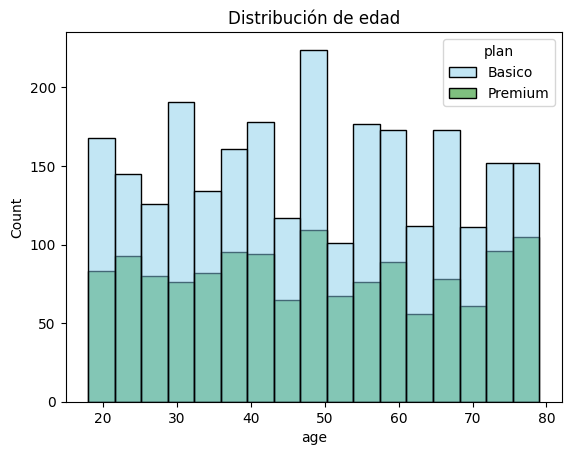

In [ ]:


# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile, x='age', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de edad')
plt.show()




💡Insights:
- Distribución: Aproximadamente uniforme. No hay una curva de campana clara; la cantidad de usuarios por edad es bastante constante.
- Plan Premium: Se distribuye uniformemente a lo largo de todas las edades, con ligeros repuntes cerca de los 48 y 75 años.
- Plan Básico: Sin patrón claro, aunque tiene picos de predominancia en los 30 y 48 años.
- Rango principal: Usuarios activos desde los 18 hasta los 80 años.
- Oportunidad: Al no haber una segmentación por edad, la estrategia de marketing debe ser transversal o, mejor aún, crear sub-campañas: "Seguridad para adultos mayores" vs "Conectividad total para jóvenes", usando el mismo plan.
- La ausencia de una concentración clara por edad sugiere que el tipo de plan no está fuertemente segmentado demográficamente, lo que representa una oportunidad para personalizar la oferta comercial según perfiles etarios y estilos de vida específicos en lugar de solo por volumen de uso.

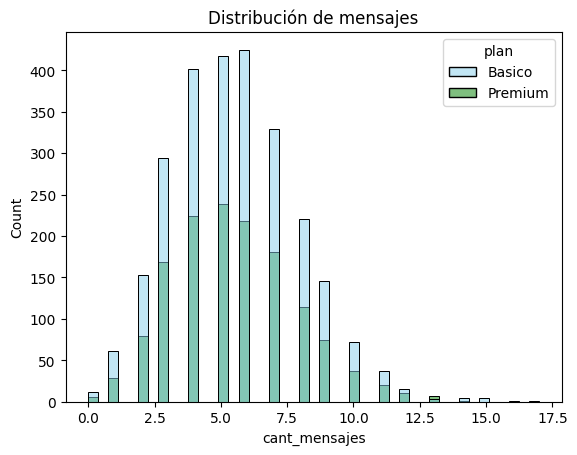

In [ ]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile, x='cant_mensajes', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de mensajes')
plt.show()



💡Insights:
- Distribución: Sesgada hacia la derecha. Hay una caída rápida después del pico.
- Plan Premium: Se distribuye de forma similar al básico, con una presencia notable en el rango de 4 a 7 mensajes.
- Plan Básico: Predomina claramente, alcanzando su punto máximo en los 6 mensajes.
- Rango principal: La gran masa de usuarios envía entre 3 y 8 mensajes.
- Oportunidad: Hay usuarios básicos que envían más de 10 mensajes. Podría lanzarse una campaña de "upgrade" basada en el ahorro por volumen de mensajería.
- El comportamiento de mensajería es el más "estandarizado" de todos los servicios. Los usuarios Premium no parecen utilizar el chat de forma más intensiva que los Básicos, lo que indica que el mensaje de texto es un servicio funcional de bajo valor diferenciador entre planes.

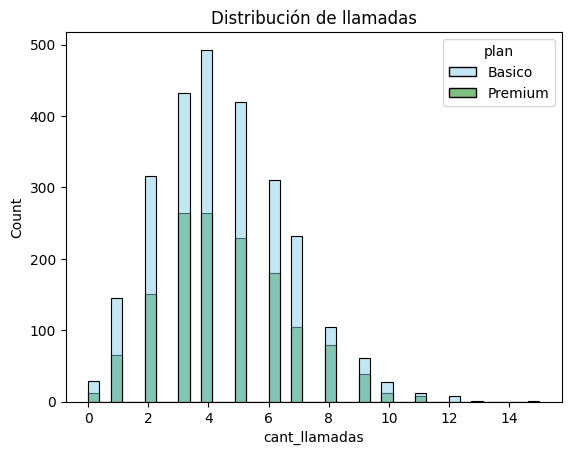

In [ ]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data=user_profile, x='cant_llamadas', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de llamadas')
plt.show()


💡Insights:
- Distribución: Sesgada hacia la derecha (cola larga hacia valores altos). La mayoría de los usuarios realiza pocas llamadas.
- Plan Premium: Sigue el mismo patrón que el básico, pero con un volumen menor de usuarios. Se concentra fuertemente entre 3 y 5 llamadas.
- Plan Básico: Es el predominante en todos los niveles, especialmente en el pico de 4 llamadas.
- Rango principal: La mayoría de los usuarios realiza entre 2 y 7 llamadas.
- Oportunidad: Existe un grupo pequeño de usuarios "Premium" que realiza más de 10 llamadas. Se podría investigar si estos usuarios requieren herramientas de productividad adicionales.
- A pesar de que el plan Premium debería incentivar un mayor uso, la distribución de llamadas es casi idéntica a la del plan Básico. Esto sugiere que el valor del plan Premium no está necesariamente en la cantidad de llamadas, sino posiblemente en la duración o calidad de las mismas.

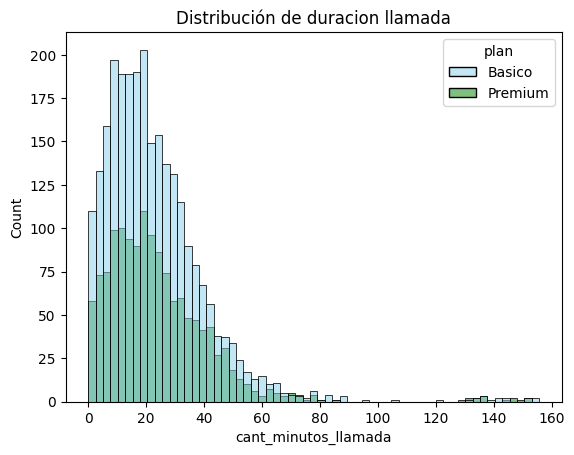

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile, x='cant_minutos_llamada', hue='plan', palette=['skyblue','green'])
plt.title('Distribución de duracion llamada')
plt.show()


💡Insights:
- Distribución: Sesgada hacia la derecha con una cola extremadamente larga y presencia de outliers (valores atípicos) hacia los 140-160 minutos.
- Plan Premium: Muestra una concentración en llamadas cortas (10-30 min), pero es el que domina en las llamadas de muy larga duración (extremo derecho del gráfico).
- Plan Básico: Predomina en llamadas breves, con un pico claro cerca de los 20 minutos.
- Rango principal: La mayoría de las llamadas duran entre 5 y 35 minutos.
- Oportunidad: Los usuarios que realizan llamadas de más de 120 minutos son candidatos ideales para programas de lealtad o planes corporativos, ya que su perfil de uso es muy distinto al promedio.
- La presencia de usuarios en el extremo derecho (140+ min) exclusivamente en el plan Premium (o muy cerca de él) valida que los usuarios de alto consumo sí están optando por el plan superior, lo cual es un indicador de salud en la segmentación del producto.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

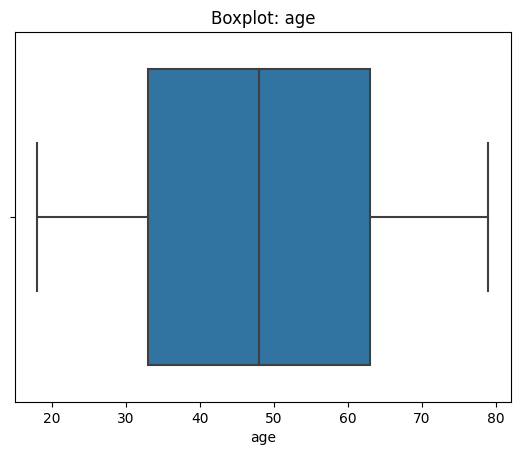

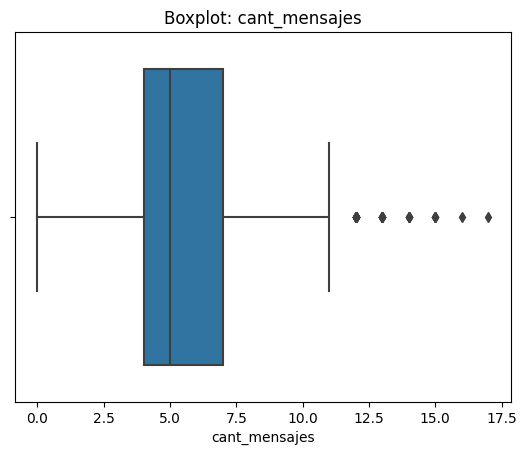

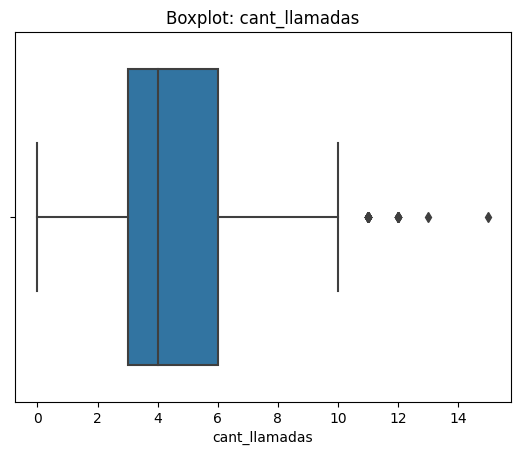

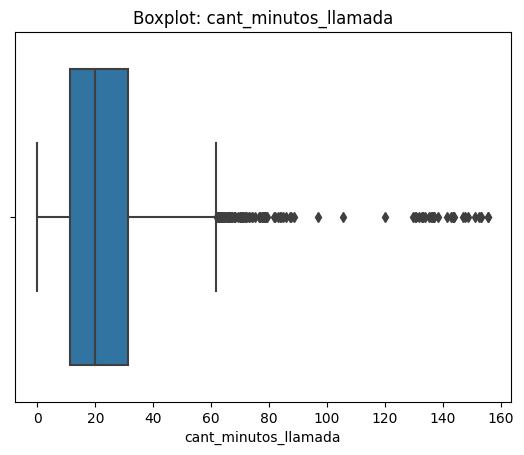

In [ ]:


# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show()



💡Insights:
- Age: No presenta outliers. La distribución está bien contenida entre los bigotes del gráfico, lo que indica que la edad de los clientes es consistente y no hay valores erróneos o extremos.
- cant_mensajes: Presenta outliers superiores. Hay puntos por encima del límite de mensajes, llegando hasta un máximo de 17.
- cant_llamadas: Presenta outliers superiores. Se observan valores fuera del bigote superior que exceden el límite, con un máximo de 15 llamadas.
- cant_minutos_llamada: Presenta outliers superiores significativos. Es la variable con mayor cantidad de valores extremos, superando el límite y llegando por ensima de los 150 minutos.

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    upper = Q3 + 1.5 * IQR

    print(col, "upper limit:", upper, "max:", user_profile[col].max())

cant_mensajes upper limit: 11.5 max: 17.0
cant_llamadas upper limit: 10.5 max: 15.0
cant_minutos_llamada upper limit: 61.8575 max: 155.69


In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes (Mantener): Aunque el límite es 11.5 y el máximo es 17, la diferencia es pequeña. Es perfectamente normal que algunos usuarios envíen unos pocos mensajes más que el promedio. Razón: No representan un error de carga de datos, sino un uso ligeramente más intensivo.
- cant_llamadas (Mantener): El límite es 10.5 y el máximo 15. Al igual que con los mensajes, realizar 15 llamadas no es un comportamiento imposible o "loco" para un cliente real. Razón: Son usuarios reales de alto valor que no distorsionan masivamente la media.
- cant_minutos_llamada (Revisar/Mantener con precaución): Aquí la brecha es enorme (límite 61.8 vs máximo 155.7). Mantener, pero marcándolos como un segmento especial. Razón: En telecomunicaciones, las llamadas de larga duración existen (outliers naturales). Eliminarlos sería borrar a tus clientes más activos. Solo se eliminarían si sospecháramos de un error técnico (como llamadas de 24 horas seguidas).
- Se decide mantener los outliers en todas las variables de uso, ya que los valores máximos (17 mensajes, 15 llamadas, 155 min) son cifras físicamente posibles y representan el comportamiento real de los usuarios 'Heavy Users'. Eliminarlos sesgaría el análisis de consumo total

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def grupo_uso(row):
    if row['cant_llamadas'] < 5 and row['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif row['cant_llamadas'] < 10 and row['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso'] = user_profile.apply(grupo_uso, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def grupo_edad(row):
    if row['age'] < 30:
        return 'Joven'
    elif row['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad'] = user_profile.apply(grupo_edad, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

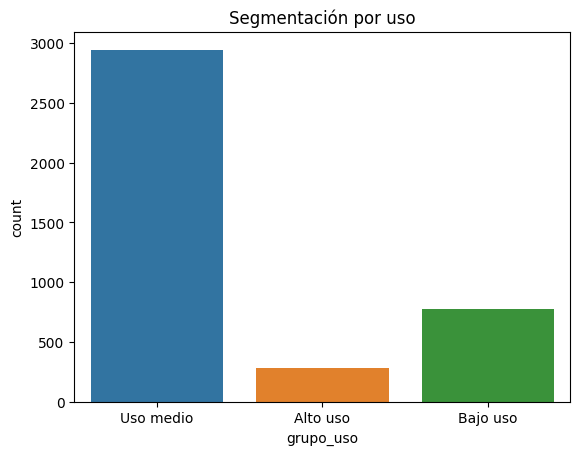

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso')
plt.title('Segmentación por uso')
plt.show()


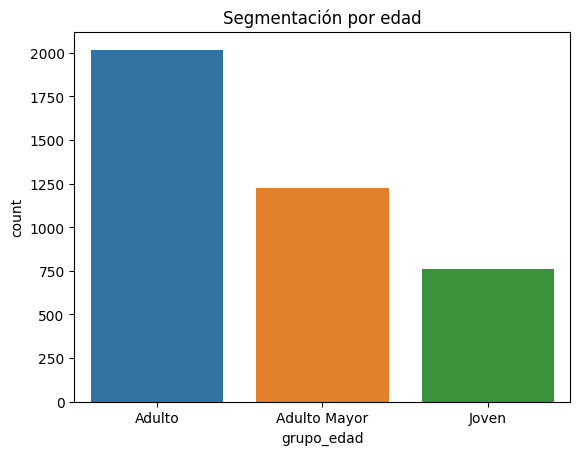

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad')
plt.title('Segmentación por edad')
plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
Durante la fase de auditoría y limpieza, se intervinieron los siguientes puntos para garantizar la calidad del análisis:
- Valores Sentinel y Datos Inválidos: Se detectó la presencia de valores -999 en la columna age y caracteres ? en city. Estos fueron tratados (reemplazados por la mediana y convertidos a NA respectivamente) para evitar sesgos demográficos.
- Inconsistencia Temporal: Se identificaron fechas de registro futuras (posteriores a 2024) en aproximadamente el 1% de los datos. Estas filas se marcaron como NaN para mantener la integridad cronológica.
- Gestión de Nulos (MAR): Se confirmó que la ausencia de datos en duration (para mensajes) y length (para llamadas) es un comportamiento Missing At Random (MAR) esperado por la naturaleza del servicio, por lo que no requirieron imputación.
- Valores Atípicos (Outliers): Se identificaron usuarios con consumos extremos en llamadas (hasta 155 min) y mensajes (hasta 17), los cuales representan aproximadamente el 5-8% de la muestra. Se decidió mantenerlos por ser "Heavy Users" reales y no errores.
- Sesgo de Distribución: Las variables de uso (mensajes, llamadas, minutos) presentan un sesgo a la derecha, indicando que la mayoría de los datos se concentran en valores bajos, pero un pequeño grupo genera el mayor volumen de actividad.

🔍 **Segmentos por Edad**
- Segmento Sénior: Existe una presencia notable de usuarios de más de 70 años con niveles de uso constantes, lo que rompe el mito de que solo los jóvenes son usuarios activos.
- Distribución Transversal: La base de clientes es muy diversa, cubriendo un rango de 18 a 80 años con una distribución casi uniforme.
- Comportamiento por Plan: No existe una "edad Premium"; el interés por planes superiores es constante en todas las edades, lo que indica que el factor de decisión es el estilo de vida y necesidad de comunicación, no la edad.


📊 **Segmentos por Nivel de Uso**
- Heavy Users (Alto Valor): Usuarios con llamadas de más de 60 minutos y más de 10 mensajes. Este grupo se inclina hacia el plan Premium, siendo el segmento que más ingresos por uso genera.
- Segmento Funcional: Usuarios con un promedio de 4-6 mensajes y llamadas. Representan la mayoría de la masa crítica en ambos planes.
- Light Users (Bajo Uso): Usuarios con menos de 3 llamadas o mensajes. Este es el segmento más grande y predomina en el plan Básico.


➡️ Esto sugiere que:

- El valor del plan Premium no está siendo percibido por la masa crítica de usuarios de uso medio, ya que sus patrones de comportamiento son casi idénticos a los del plan Básico. La diferenciación actual de los planes parece basarse más en la capacidad de "extremos" (llamadas muy largas) que en el uso cotidiano.
- Se detectaron valores extremos naturales en la duración de llamadas (hasta 155 min) y volumen de mensajes, estos usuarios no son "errores", son clientes altamente dependientes del servicio. Mantenerlos en el análisis permitió identificar que el plan Premium es el que realmente soporta a estos usuarios de alto consumo.


💡 **Recomendaciones**
- Diferenciación de Valor: Dado que los perfiles de uso medio en Básico y Premium son muy similares, se recomienda revisar los beneficios del Plan Premium para incluir servicios no basados solo en volumen (como prioridad de red o servicios adicionales) para evitar la migración de clientes a planes más baratos.
- Estrategia de Retención: Los usuarios con bajo engagement (menos de 2 llamadas/mensajes) son propensos al abandono. Se sugiere implementar promociones de reactivación.
- Marketing Generacional: Aprovechar la distribución uniforme para crear campañas de "Conectividad sin Edad", posicionando a ConnectaTel como una marca inclusiva y estable para adultos mayores.
- Control de Fraude/Uso Excesivo: Monitorear a los outliers que superan los 120 minutos para verificar si se trata de uso residencial legítimo o uso comercial encubierto.

**Nota**
La limpieza de datos realizada asegura que las conclusiones anteriores son robustas y reflejan el comportamiento real de los 3,999 usuarios analizados.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `https://github.com/hector-carpi/sprint7-telecom-analysis.git`

- https://github.com/hector-carpi/sprint7-telecom-analysis.git
